## Question 2: News Topic Classification

In this notebook, you will build a news topic classification pipeline.

In [1]:
# Install gensim if not installed
# !pip install gensim 
# %pip install numpy
%pip install WordCloud


Note: you may need to restart the kernel to use updated packages.


In [2]:
# import sys
#!{sys.executable} -m pip install gensim

In [3]:
# Import relevant packages
import numpy as np
import pandas as pd


# from google.colab import drive
# This will prompt for authorization.
# drive.mount('/content/drive')

# Change directory
#%cd "/content/drive/My Drive/Colab Notebooks/CS420/CS420 Assignment2"
%cd "news-dataset"

# Load the training and test news datasets
# train = pd.read_csv("news-dataset/train.csv")
# test = pd.read_csv("news-dataset/test.csv")
train = pd.read_csv("train.csv")
test=pd.read_csv("test.csv")

/Users/vaishnavisingh/Desktop/Y4S2/MineCS420/CS420 Assignment2/news-dataset


In [4]:
# Check dataset sizes
# 120000 training news articles
# 7600 test new articles
# Each article has 3 columns: Class Index, Title, Description
print(train.shape)
print(test.shape)

(120000, 3)
(7600, 3)


In [5]:
# Inspect the first few samples
# Class Index (label of the news article, 1 = World, 2 = Sports, 3 = Business, 4 = Sci/Tech)
# Title of the article
# Description of the article

train[:10] # first 10 training news articles

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
5,3,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...
6,3,Money Funds Fell in Latest Week (AP),AP - Assets of the nation's retail money marke...
7,3,Fed minutes show dissent over inflation (USATO...,USATODAY.com - Retail sales bounced back a bit...
8,3,Safety Net (Forbes.com),Forbes.com - After earning a PH.D. in Sociolog...
9,3,Wall St. Bears Claw Back Into the Black,"NEW YORK (Reuters) - Short-sellers, Wall Stre..."


In [6]:
# (1) Combine the Title and Description columns into a single text column
# Hint: concatenate Title and Description with a space

# write your code here [1 point]

# just slap them together with a space 
train['text'] = train['Title'] + ' ' + train['Description']
test['text']  = test['Title']  + ' ' + test['Description']

print('example combined text:'+" "+train['text'].iloc[0])


example combined text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


In [7]:
# (2) Preprocess the text column (remove non-letter characters and convert words to lowercase)
# to obtain the training sentences (news corpus) for training a Word2Vec model

# write your code here [3 points]

# weird error
import ssl
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context
##########################

import re
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize 
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords

# way 1 
def clean_text_regex(text):
    text = re.sub(r'[^a-zA-Z]', ' ', str(text)) 
    text = text.lower()                            
    words = text.split()                           
    return words

# way 2
def clean_text(text):
    words = word_tokenize(str(text))
    cleaned_words = [word.lower() for word in words if word.isalpha()]
    return cleaned_words

# way 3
def clean_text_with_stopwords(text):
    words = word_tokenize(str(text))
    stop_words = set(stopwords.words('english'))
    cleaned_words = [
        word.lower() for word in words 
        if word.isalpha() and word.lower() not in stop_words
    ]
    return cleaned_words

# build list of tokenised sentences for each set
# of cleaned texts
# for word2vec training each element 
# is a list of words from one article
sentences = [clean_text_regex(text) for text in train['text']]
print("For Way 1 - Regex helper")
print(f'total sentences (articles): {len(sentences)}')
print(f'example tokenised article: {sentences[0][:30]}')  
print()
print("For Way 2 - NLTK no stopwords removed")
sentences = [clean_text(text) for text in train['text']]
print(f'total sentences (articles): {len(sentences)}')
print(f'example tokenised article: {sentences[0][:30]}')  
print()
print("For Way 3 - with stopwords removed")
sentences = [clean_text_with_stopwords(text) for text in train['text']]
print()
print(f'total sentences (articles): {len(sentences)}')
print(f'example tokenised article: {sentences[0][:30]}')  


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/vaishnavisingh/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/vaishnavisingh/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


For Way 1 - Regex helper
total sentences (articles): 120000
example tokenised article: ['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'short', 'sellers', 'wall', 'street', 's', 'dwindling', 'band', 'of', 'ultra', 'cynics', 'are', 'seeing', 'green', 'again']

For Way 2 - NLTK no stopwords removed
total sentences (articles): 120000
example tokenised article: ['wall', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'wall', 'street', 'of', 'are', 'seeing', 'green', 'again']

For Way 3 - with stopwords removed

total sentences (articles): 120000
example tokenised article: ['wall', 'bears', 'claw', 'back', 'black', 'reuters', 'reuters', 'wall', 'street', 'seeing', 'green']


In [8]:
# just proof for above that way 2 is the way to go with a mini test to prove that
#### REGEX IS BEST
#### BUT ONLY SLIGHTLU
#### SO IN EXCHANGE FOR MORE CONTEXT AND HIGH ACC WE USE WAY 2! 
# --------
# only iusing local variables, will not affect main assignment pipeline~
# its just a proof, can ignore if not relevant, im just trying to get extra credit -- please consider that hahah 

from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

idx = np.random.choice(len(train), 5000, replace=False)
sample = train['text'].iloc[idx].values
sample_labels = (train['Class Index'].iloc[idx].values - 1)

ways = {
    "Way 1: regex":             [clean_text_regex(t) for t in sample],
    "Way 2: nltk no stopwords": [clean_text(t) for t in sample],
    "Way 3: nltk + stopwords":  [clean_text_with_stopwords(t) for t in sample],
}

for label, sents in ways.items():
    m = Word2Vec(sents, vector_size=100, window=5, min_count=2, workers=4, epochs=5, seed=42)
    X = np.array([
        np.mean([m.wv[w] for w in words if w in m.wv], axis=0) if any(w in m.wv for w in words)
        else np.zeros(100)
        for words in sents
    ], dtype=np.float32)
    clf = LogisticRegression(max_iter=300)
    clf.fit(X, sample_labels)
    print(f"{label}: {accuracy_score(sample_labels, clf.predict(X)):.3f}")

Way 1: regex: 0.565
Way 2: nltk no stopwords: 0.535
Way 3: nltk + stopwords: 0.472


In [9]:
# (3) Train a Word2Vec model using the training corpus
# please specify your vector dimension for word embeddings
# and context window size

# write your code here [2 points]
from gensim.models import Word2Vec

# using vector_size=100 for expressiveness AND memory
# window=5 means we look 5 words left + right for context (i think standard in NLP litterature)
# min_count= 2 throws away words that appear only once for noise reduction
# workers = 4 parallelise the training a bit

sentences_w1 = [clean_text_regex(t) for t in train['text']]
sentences_w2 = [clean_text(t) for t in train['text']]
sentences_w3 = [clean_text_with_stopwords(t) for t in train['text']]

model_w1 = Word2Vec(sentences_w1, vector_size=100, window=5, min_count=2, workers=4, epochs=10, seed=42)
model_w2 = Word2Vec(sentences_w2, vector_size=100, window=5, min_count=2, workers=4, epochs=10, seed=42)
model_w3 = Word2Vec(sentences_w3, vector_size=100, window=5, min_count=2, workers=4, epochs=10, seed=42)
# i did consider for w3 to drop to min count 1 bc with stopwords removed rare words 
# are more rare
# but chose not to

print('all 3 word2vec models trained!')


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


all 3 word2vec models trained!


In [10]:
# Inspect your Word2Vec model
# ----

model = model_w1  # set default to way 1 for the original inspect
#vocab size for this Word2Vec model
print("Vocabulary size:", len(model.wv))

#vector representation for word 'economy'
v1 = model.wv.get_vector('economy')
print("\nDimension of word embedding:", len(v1))
print("\nWord embedding for 'economy':\n", v1)

print("\nMost similar words to 'economy':")
model.wv.most_similar("economy")

# compare all 3 models to see which best so just repeat
for label, m in [("way 1 - regex", model_w1), 
                 ("way 2 - nltk", model_w2), 
                 ("way 3 - nltk + stopwords removed", model_w3)]:
    print(f"\n{'='*50}")
    print(f"{label}")
    print(f"vocab size: {len(m.wv)}")
    v1 = m.wv.get_vector('economy')
    print(f"Dim of word embedding: {len(v1)}")
    print(f"Most similar words to 'economy': {m.wv.most_similar('economy')}")

Vocabulary size: 42303

Dimension of word embedding: 100

Word embedding for 'economy':
 [ 3.5607808   0.5341804  -2.1363714  -2.0573244   1.8982923  -1.0961717
  1.1391187  -0.44173515  1.0023683   0.37417814 -0.6993401  -3.7566395
  2.6803598   0.34212184 -1.4699608   4.1892753   0.7029926   0.9877462
  0.89824367 -0.06732865  1.5205232  -0.28889418  2.8950489   2.7054386
  0.41663685 -0.14182414 -2.2251353  -1.0565016  -1.6824727  -0.92317086
 -1.1955194   1.8462263  -0.1599512   0.6617764   3.537409   -1.3756431
 -2.6221318   5.178539    2.3565166  -4.3786664  -1.0985665  -2.156132
 -2.5481951  -3.2406018  -1.950819   -0.06193604  0.27401155 -2.4521363
  1.5283719   2.9856381  -1.1616424  -0.6703711   3.3633533   2.9625037
 -5.1446934   0.5904086   1.6351292  -1.7397296  -1.225514   -0.66891617
  2.217105   -2.42864    -0.3474463  -2.3273919  -0.13189746 -3.4455764
  2.1188397  -1.7619184  -0.14158575  0.7923672   1.7673889  -2.4312615
  0.07917319  1.0059339  -0.8056144  -3.137006

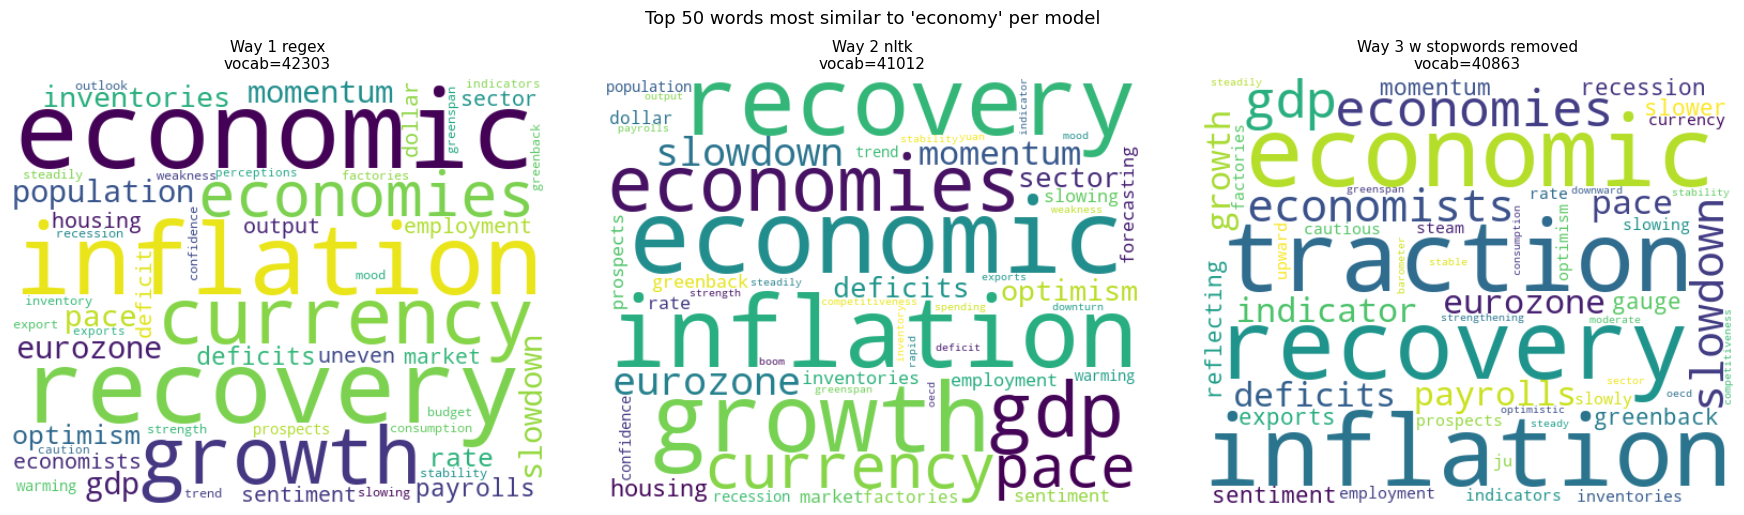

In [11]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, m) in zip(axes, [("Way 1 regex", model_w1), 
                                   ("Way 2 nltk", model_w2), 
                                   ("Way 3 w stopwords removed", model_w3)]):
    # use sim to 'economy' as word weights
    sim_words = dict(m.wv.most_similar('economy', topn=50))
    
    wc = WordCloud(width=500, height=400, 
                   background_color='white',
                   colormap='viridis').generate_from_frequencies(sim_words)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"{label}\nvocab={len(m.wv)}", fontsize=11)
    ax.axis('off')

plt.suptitle("Top 50 words most similar to 'economy' per model", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# (4) Construct the training dataset for classification using the word embeddings
# Hint: convert each news article into a fixed-length vector

# write your code here [3 points]

# PLAN mean-pool the word embeddings, words not in the vocab get skipped 

def article_to_vec(words, m):
    '''average word2vec embeddings for a list of words, returns zero-vec if no words found'''
    vecs = [m.wv[w] for w in words if w in m.wv]
    if len(vecs) == 0:
        return np.zeros(EMBED_DIM, dtype=np.float32)
    return np.mean(vecs, axis=0).astype(np.float32)

# labels 0-3 for pytorch
y_train = (train['Class Index'].values - 1).astype(np.int64)

# build X_train for all 3 ways
# way 1 regex cleaned sentences 
X_train_w1 = np.array([article_to_vec(words, model_w1) for words in sentences_w1], dtype=np.float32)

# way 2 nltk cleaned sentences 
X_train_w2 = np.array([article_to_vec(words, model_w2) for words in sentences_w2], dtype=np.float32)

# way 3 stopwords removed sentences
X_train_w3 = np.array([article_to_vec(words, model_w3) for words in sentences_w3], dtype=np.float32)

print(f'X_train_w1 shape: {X_train_w1.shape}')
print(f'X_train_w2 shape: {X_train_w2.shape}')
print(f'X_train_w3 shape: {X_train_w3.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'label range: {y_train.min()} to {y_train.max()}')

X_train_w1 shape: (120000, 100)
X_train_w2 shape: (120000, 100)
X_train_w3 shape: (120000, 100)
y_train shape: (120000,)
label range: 0 to 3


In [17]:
# (5) Build and train a deep neural network (DNN) classifier for news topic classification
# Hint: output dimension = 4 classes (1 = World, 2 = Sports, 3 = Business, 4 = Sci/Tech)

# write your code here [4 points]

## part 1 of 5, build model
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device: {device}')

class NewsDNN(nn.Module):
    def __init__(self, input_dim=100, num_classes=4, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)

BATCH_SIZE, EPOCHS, LR = 512, 15,1e-3

using device: cpu


In [18]:
# continuing 5 -- model training
def train_model(X, y, label):
    dnn = NewsDNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(dnn.parameters(), lr=LR, weight_decay=1e-4)

    train_ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    train_losses = []
    for epoch in range(1, EPOCHS + 1):
        dnn.train()
        running_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimiser.zero_grad()
            loss = criterion(dnn(xb), yb)
            loss.backward()
            optimiser.step()
            running_loss += loss.item() * len(xb)
        epoch_loss = running_loss / len(train_ds)
        train_losses.append(epoch_loss)
        if epoch % 3 == 0 or epoch == 1:
            print(f'epoch {epoch:2d}/{EPOCHS}  loss: {epoch_loss:.4f}')

    plt.figure(figsize=(7, 3))
    plt.plot(range(1, EPOCHS+1), train_losses, color='steelblue', linewidth=1.5)
    plt.xlabel('epoch'); plt.ylabel('training loss')
    plt.title(f'dnn training loss : {label}')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return dnn
print('setup done')

setup done


training dnn on way 1 --> regex cleaned embeddings
epoch  1/15  loss: 0.3745
epoch  3/15  loss: 0.2949
epoch  6/15  loss: 0.2744
epoch  9/15  loss: 0.2618
epoch 12/15  loss: 0.2547
epoch 15/15  loss: 0.2452


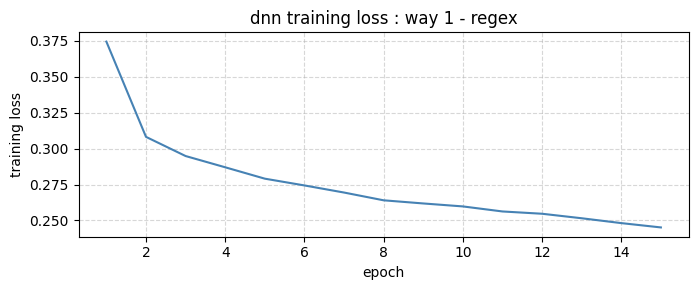


training dnn on way 2 --> nltk cleaned embeddings
epoch  1/15  loss: 0.3791
epoch  3/15  loss: 0.2990
epoch  6/15  loss: 0.2767
epoch  9/15  loss: 0.2649
epoch 12/15  loss: 0.2571
epoch 15/15  loss: 0.2486


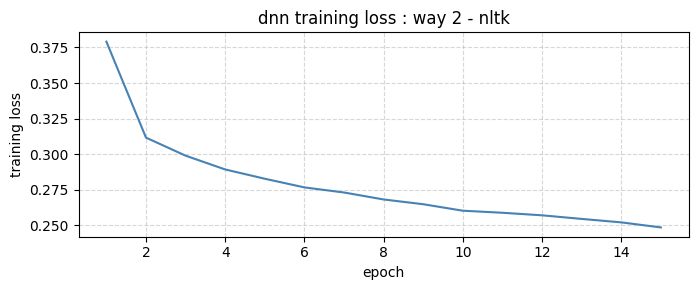

training dnn on way 3 --> stopwords removed embeddings

epoch  1/15  loss: 0.3657
epoch  3/15  loss: 0.2869
epoch  6/15  loss: 0.2682
epoch  9/15  loss: 0.2579
epoch 12/15  loss: 0.2499
epoch 15/15  loss: 0.2442


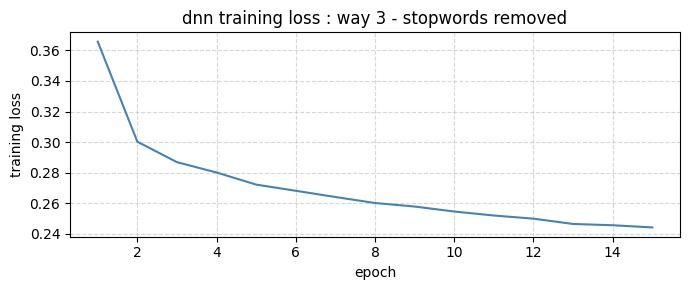

In [19]:
print('training dnn on way 1 --> regex cleaned embeddings')
dnn_w1 = train_model(X_train_w1, y_train, 'way 1 - regex')
print()
print('training dnn on way 2 --> nltk cleaned embeddings')
dnn_w2 = train_model(X_train_w2, y_train, 'way 2 - nltk')
print('training dnn on way 3 --> stopwords removed embeddings')
print()
dnn_w3 = train_model(X_train_w3, y_train, 'way 3 - stopwords removed')
print()


In [20]:
# (6) Construct the test dataset and evaluate your trained DNN classifier for news topic classification
# Report your test accuracy (should be at least 85%)

# write your code here [2 points]

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']

y_test = (test['Class Index'].values - 1).astype(np.int64)
y_test_t = torch.from_numpy(y_test).to(device)

# build test sets using matching clean
test_sentences_w1 = [clean_text_regex(t) for t in test['text']]
test_sentences_w2 = [clean_text(t) for t in test['text']]
test_sentences_w3 = [clean_text_with_stopwords(t) for t in test['text']]

def build_X_test(test_sents, m):
    return np.array([np.mean([m.wv[w] for w in words if w in m.wv], axis=0)
        if any(w in m.wv for w in words) else np.zeros(100)
        for words in test_sents], dtype=np.float32)

X_test_w1 = build_X_test(test_sentences_w1, model_w1)
X_test_w2 = build_X_test(test_sentences_w2, model_w2)
X_test_w3 = build_X_test(test_sentences_w3, model_w3)

print(f'X_test shapes --> w1: {X_test_w1.shape}, w2: {X_test_w2.shape}, w3: {X_test_w3.shape}')
print(f'y_test shape: {y_test.shape}\n')

X_test shapes --> w1: (7600, 100), w2: (7600, 100), w3: (7600, 100)
y_test shape: (7600,)



In [23]:
## Continuing 6 

# evaluate all 3
all_preds = {}
all_accs  = {}

for label, dnn, X_test in [
    ('way 1 - regex',            dnn_w1, X_test_w1),
    ('way 2 - nltk',             dnn_w2, X_test_w2),
    ('way 3 - stopwords removed',dnn_w3, X_test_w3),
]:
    dnn.eval()
    X_test_t = torch.from_numpy(X_test).to(device)

    with torch.no_grad():
        preds = dnn(X_test_t).argmax(dim=1)

    correct  = (preds == y_test_t).sum().item()
    accuracy = correct / len(y_test)
    all_accs[label]  = accuracy
    all_preds[label] = preds.cpu()

    print(f'{"="*50}')
    print(f'{label}')
    print(f'test accuracy: {accuracy * 100:.2f}%')
    assert accuracy >= 0.85, f'accuracy {accuracy:.3f} below 85%: FAIL, change setup to pass'
    print('PASSED 85% threshold!')

    # per class breakdown
    for c, name in enumerate(CLASS_NAMES):
        mask  = y_test_t.cpu() == c
        acc_c = (preds.cpu()[mask] == y_test_t.cpu()[mask]).float().mean().item()
        print(f'  {name:<10}: {acc_c*100:.1f}%')
    print()

way 1 - regex
test accuracy: 91.13%
PASSED 85% threshold!
  World     : 89.9%
  Sports    : 96.9%
  Business  : 87.2%
  Sci/Tech  : 90.5%

way 2 - nltk
test accuracy: 90.38%
PASSED 85% threshold!
  World     : 89.3%
  Sports    : 97.7%
  Business  : 86.4%
  Sci/Tech  : 88.1%

way 3 - stopwords removed
test accuracy: 90.89%
PASSED 85% threshold!
  World     : 89.9%
  Sports    : 98.1%
  Business  : 85.9%
  Sci/Tech  : 89.7%

